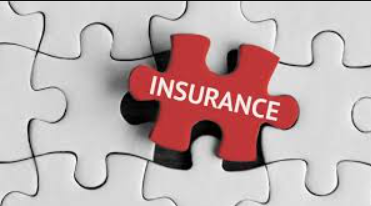

# Business Problem

Insurance companies need to estimate the medical insurance costs of individuals accurately to optimize pricing strategies, minimize risks, and ensure profitability. Incorrect estimations can lead to financial losses for insurers and unfair pricing for customers.

In this project, we aim to build a predictive model that estimates insurance costs based on demographic and health-related factors such as age, BMI, smoking status, and region. By leveraging machine learning techniques, we strive to enhance cost prediction accuracy, helping insurance providers set fair premiums and improve customer satisfaction.

# Dataset Story

This dataset contains information about individuals who are insured, with the target variable being the charges they incur for their insurance policies. The data was collected with the aim of understanding how various factors influence medical costs and to assist in the development of better insurance models.

Features:

**Age**: The age of the individual in years. It is expected that older individuals might incur higher medical charges due to age-related health conditions.

**Sex**: The gender of the individual (male/female). Gender differences might affect insurance charges due to varying health risk profiles between men and women.

**BMI (Body Mass Index)**: A measure of body fat based on height and weight. Higher BMI values can indicate a greater risk for certain health conditions, potentially leading to higher insurance costs.

**Children**: The number of children or dependents the individual has. This feature might indicate the individual's family size, which could be a factor in their overall healthcare needs.

**Smoker**: Whether the individual is a smoker (yes/no). Smoking is a known risk factor for a variety of health issues, which may contribute to higher medical costs.

**Region**: The geographical region where the individual lives. Different regions might have varying healthcare costs, which could influence insurance charges.

**Charges**: The target variable representing the medical charges incurred by the individual. This is the value we aim to predict based on the other features.

By analyzing this data, we aim to uncover insights into how each feature affects the overall insurance charges and develop a predictive model to help insurers better estimate costs for potential clients.

# Road Map

1. Import Required Libaries
2. Adjusting Row Column Settings
3. Loading The Dataset
4. Exploratory Data Analysis
5. Capturing / Detecting Numeric and Categorical Variables
6. Analysis of Categorical Variables
7. Analysis of Numerical Variables
8. Analysis of Categorical Variables by Target
9. Analysis of Numeric Variables by Target
10. correlation Analysis
11. The Relationship Between Variables
12. Outlier Analysis
13. Missing Value Analysis
14. Feature Extraction
15. Encoding
16. Standardization Process
17. Creating Model
18. Hyperparameter Optimization
19. Feature Importance
20. Final Model

# 1. Import Required Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/insurance/insurance.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import itertools
import plotly.graph_objects as go
import time

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.metrics import classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV, ShuffleSplit, StratifiedKFold
from sklearn.model_selection import GridSearchCV, cross_validate, RandomizedSearchCV, validation_curve
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.simplefilter(action="ignore")

import warnings
warnings.simplefilter(action="ignore")

# 2. Adjusting Row Column Settings

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# 3. Loading The Dataset

In [4]:
df = pd.read_csv("/kaggle/input/insurance/insurance.csv")

# 4. Exploratory Data Analysis

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [6]:
def check_df(dataframe, head=5):
    print('##################### Shape #####################')
    print(dataframe.shape)
    print('##################### Types #####################')
    print(dataframe.dtypes)
    print('##################### Head #####################')
    print(dataframe.head(head))
    print('##################### Tail #####################')
    print(dataframe.tail(head))
    print('##################### NA #####################')
    print(dataframe.isnull().sum())
    print('##################### Quantiles #####################')
    print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

check_df(df)

##################### Shape #####################
(1338, 7)
##################### Types #####################
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
##################### Head #####################
   age     sex    bmi  children smoker     region   charges
0   19  female 27.900         0    yes  southwest 16884.924
1   18    male 33.770         1     no  southeast  1725.552
2   28    male 33.000         3     no  southeast  4449.462
3   33    male 22.705         0     no  northwest 21984.471
4   32    male 28.880         0     no  northwest  3866.855
##################### Tail #####################
      age     sex    bmi  children smoker     region   charges
1333   50    male 30.970         3     no  northwest 10600.548
1334   18  female 31.920         0     no  northeast  2205.981
1335   18  female 36.850         0     no  southeast  1629.833
1336   21  female 25.800  

# 5. Capturing / Detecting Numeric and Categorical Variables

In [7]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"] 

    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]

    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]

    cat_cols = cat_cols + num_but_cat

    cat_cols = [col for col in cat_cols if col not in cat_but_car] 

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"] 

    num_cols = [col for col in num_cols if col not in num_but_cat] 
    
    print(f"Observations: {dataframe.shape[0]}") 
    print(f"Variables: {dataframe.shape[1]}") 
    print(f'cat_cols: {len(cat_cols)}') 
    print(f'num_cols: {len(num_cols)}') 
    print(f'cat_but_car: {len(cat_but_car)}') 
    print(f'num_but_cat: {len(num_but_cat)}') 


    return cat_cols, num_cols, cat_but_car, num_but_cat

In [8]:
cat_cols, num_cols, cat_but_car,  num_but_cat = grab_col_names(df)

Observations: 1338
Variables: 7
cat_cols: 4
num_cols: 3
cat_but_car: 0
num_but_cat: 1


In [9]:
cat_cols

['sex', 'smoker', 'region', 'children']

In [10]:
num_cols = ['age', 'bmi', 'charges', 'children']

# 6. Analysis of Categorical Variables

In [11]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)

        sex  Ratio
sex               
male    676 50.523
female  662 49.477
##########################################


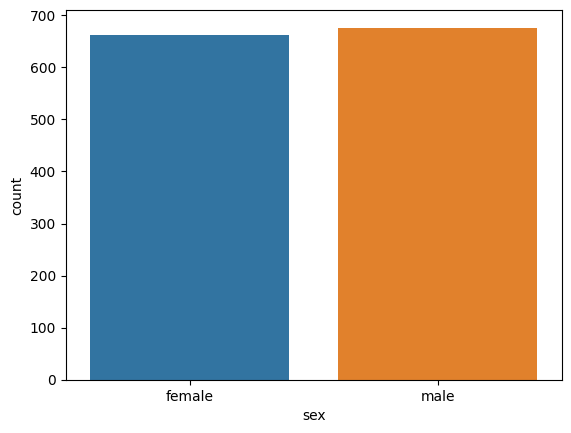

        smoker  Ratio
smoker               
no        1064 79.522
yes        274 20.478
##########################################


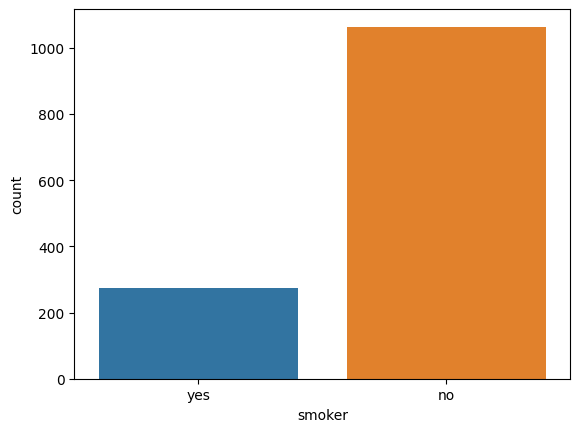

           region  Ratio
region                  
southeast     364 27.205
southwest     325 24.290
northwest     325 24.290
northeast     324 24.215
##########################################


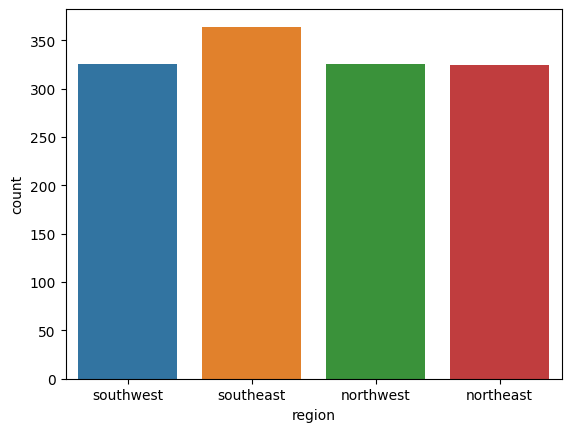

          children  Ratio
children                 
0              574 42.900
1              324 24.215
2              240 17.937
3              157 11.734
4               25  1.868
5               18  1.345
##########################################


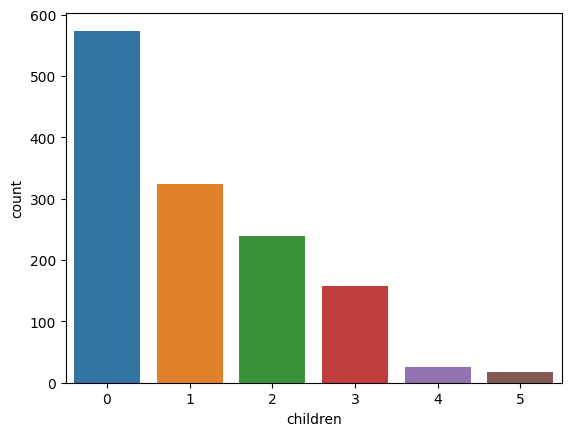

In [12]:
for col in cat_cols:
    cat_summary(df, col, plot=True)

# 7. Analysis of Numerical Variables

In [13]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

count   1338.000
mean      39.207
std       14.050
min       18.000
5%        18.000
10%       19.000
20%       24.000
30%       29.000
40%       34.000
50%       39.000
60%       44.000
70%       49.000
80%       54.000
90%       59.000
95%       62.000
99%       64.000
max       64.000
Name: age, dtype: float64


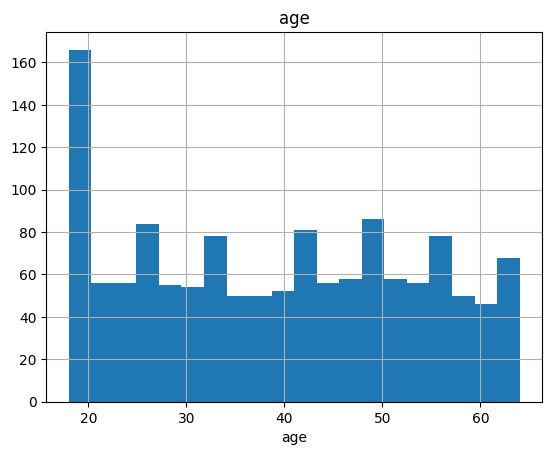

count   1338.000
mean      30.663
std        6.098
min       15.960
5%        21.256
10%       22.990
20%       25.326
30%       27.360
40%       28.797
50%       30.400
60%       32.032
70%       33.660
80%       35.860
90%       38.619
95%       41.106
99%       46.408
max       53.130
Name: bmi, dtype: float64


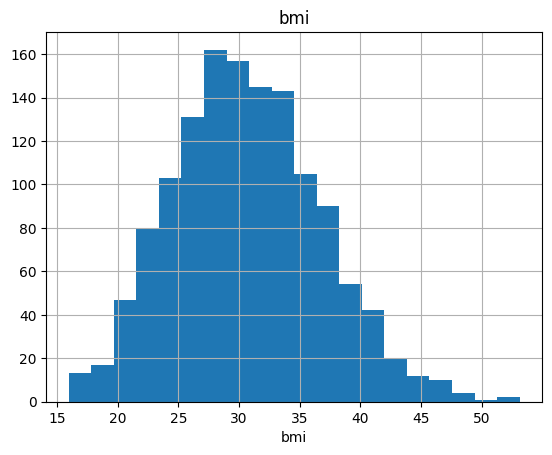

count    1338.000
mean    13270.422
std     12110.011
min      1121.874
5%       1757.753
10%      2346.534
20%      3991.576
30%      5484.847
40%      7369.053
50%      9382.033
60%     11399.857
70%     13767.875
80%     20260.626
90%     34831.720
95%     41181.828
99%     48537.481
max     63770.428
Name: charges, dtype: float64


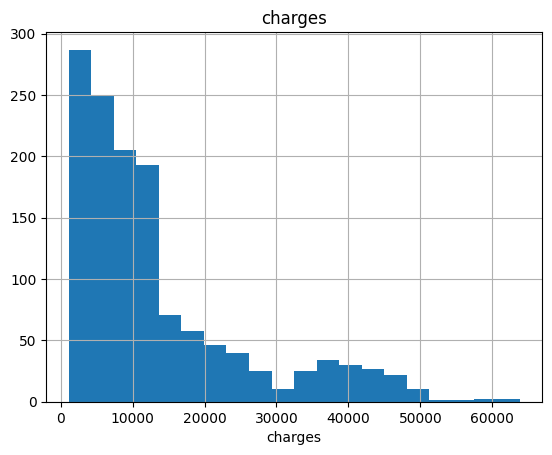

count   1338.000
mean       1.095
std        1.205
min        0.000
5%         0.000
10%        0.000
20%        0.000
30%        0.000
40%        0.000
50%        1.000
60%        1.000
70%        2.000
80%        2.000
90%        3.000
95%        3.000
99%        5.000
max        5.000
Name: children, dtype: float64


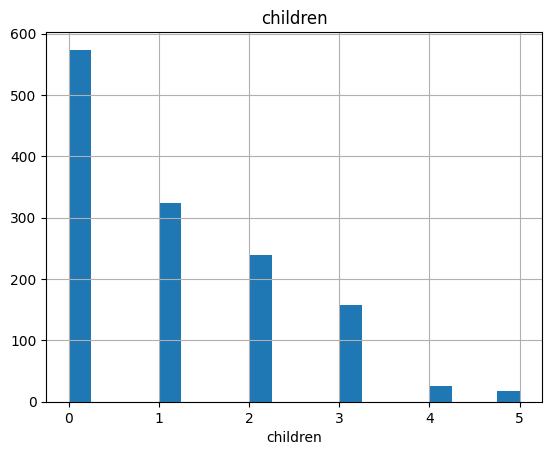

In [14]:
for col in num_cols:
    num_summary(df, col, plot=True)

# 8. Analysis of Categorical Variables by Target

In [15]:
def target_summary_with_cat(dataframe, target, categorical_col, plot=False):
    print(pd.DataFrame({'TARGET_MEAN': dataframe.groupby(categorical_col)[target].mean()}), end='\n\n\n')
    if plot:
        sns.barplot(x=categorical_col, y=target, data=dataframe)
        plt.show(block=True)

        TARGET_MEAN
sex                
female    12569.579
male      13956.751




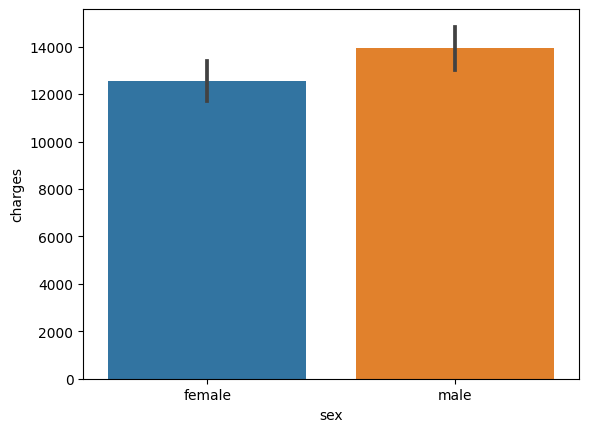

        TARGET_MEAN
smoker             
no         8434.268
yes       32050.232




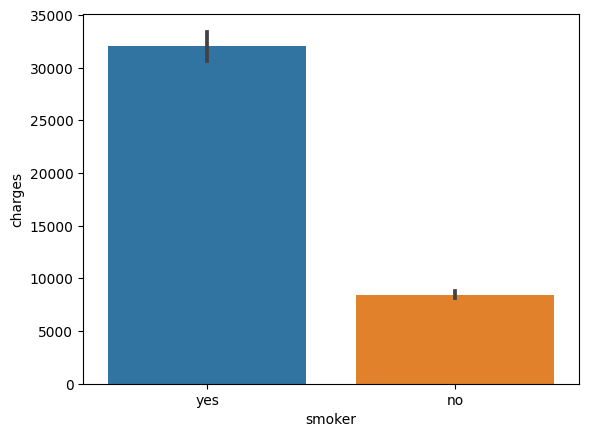

           TARGET_MEAN
region                
northeast    13406.385
northwest    12417.575
southeast    14735.411
southwest    12346.937




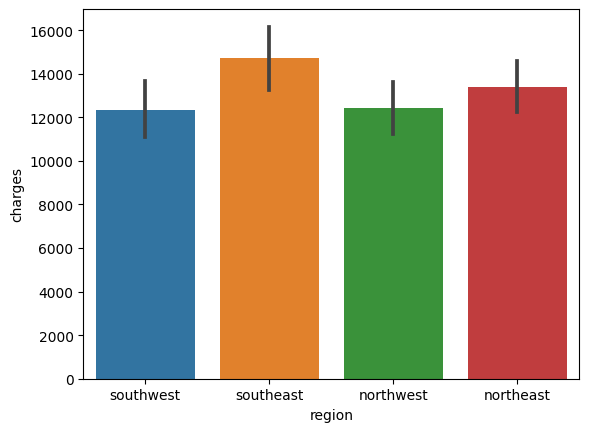

          TARGET_MEAN
children             
0           12365.976
1           12731.172
2           15073.564
3           15355.318
4           13850.656
5            8786.035




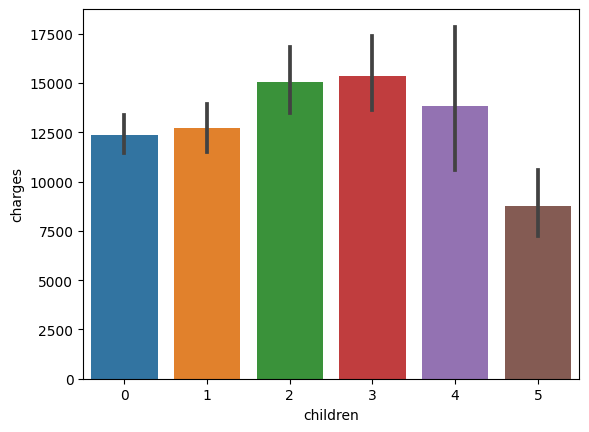

In [16]:
for col in cat_cols:
    target_summary_with_cat(df, "charges", col, plot=True)

# 9. Analysis of Numeric Variables by Target

In [17]:
def target_summary_with_num(dataframe, target, numerical_col, plot=False):
    print(pd.DataFrame({numerical_col+'_mean': dataframe.groupby(target)[numerical_col].mean()}), end='\n\n\n')
    if plot:
        sns.barplot(x=target, y=numerical_col, data=dataframe)
        plt.show(block=True)

In [18]:
for col in num_cols:
    target_summary_with_num(df, "charges", col, plot=False)

           age_mean
charges            
1121.874     18.000
1131.507     18.000
1135.941     18.000
1136.399     18.000
1137.011     18.000
...             ...
55135.402    33.000
58571.074    31.000
60021.399    52.000
62592.873    45.000
63770.428    54.000

[1337 rows x 1 columns]


           bmi_mean
charges            
1121.874     23.210
1131.507     30.140
1135.941     33.330
1136.399     33.660
1137.011     34.100
...             ...
55135.402    35.530
58571.074    38.095
60021.399    34.485
62592.873    30.360
63770.428    47.410

[1337 rows x 1 columns]


           charges_mean
charges                
1121.874       1121.874
1131.507       1131.507
1135.941       1135.941
1136.399       1136.399
1137.011       1137.011
...                 ...
55135.402     55135.402
58571.074     58571.074
60021.399     60021.399
62592.873     62592.873
63770.428     63770.428

[1337 rows x 1 columns]


           children_mean
charges                 
1121.874           0.000
1131.507    

# 10. Correlation Analysis

In [19]:
corr = df[num_cols].corr()
corr

,age,bmi,charges,children
age,1.000,0.109,0.299,0.042
bmi,0.109,1.000,0.198,0.013
charges,0.299,0.198,1.000,0.068
children,0.042,0.013,0.068,1.000


In [20]:
def high_correlated_cols(dataframe, plot=False, corr_th=0.70):
    
    # Select numerical columns
    num_cols = dataframe.select_dtypes(include=['number']).columns
    
    # Calculate correlation matrix for numerical columns
    corr = dataframe[num_cols].corr()
    
    # Get the absolute value of the correlation matrix
    cor_matrix = corr.abs()
    
    # Select the upper triangle of the correlation matrix (excluding diagonal)
    upper_triangle_matrix = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))
    
    # Get columns with high correlation above the threshold
    drop_list = [col for col in upper_triangle_matrix.columns if any(upper_triangle_matrix[col] > corr_th)]
    
    # Plot the correlation heatmap if plot=True
    if plot:
        import seaborn as sns
        import matplotlib.pyplot as plt
        sns.set(rc={"figure.figsize": (8, 6)})
        corr_values = corr.round(2)
        sns.heatmap(corr, cmap="RdBu", annot=corr_values)
        plt.show(block=True)
    
    return drop_list


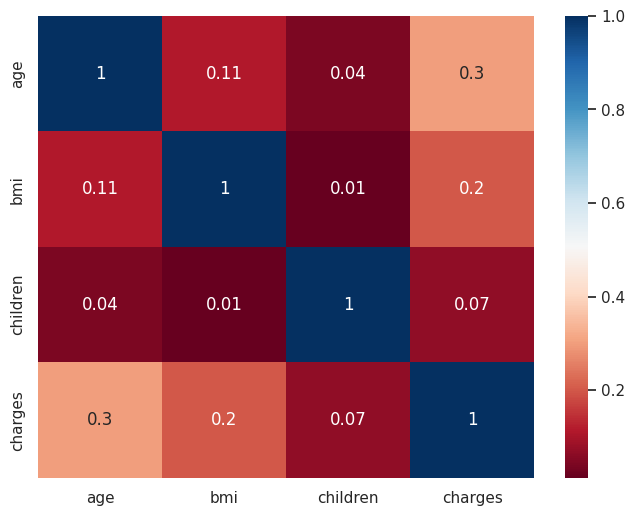

[]

In [21]:
high_correlated_cols(df, plot=True)

# 11. The Relationship Between Variables

In [22]:
# Create combinations of binary categorical variables
feature_combinations = list(itertools.combinations(['age', 'bmi', 'charges', 'children'], 2))

# Create a separate Bubble Chart for each binary categorical variable
for i, (feature1, feature2) in enumerate(feature_combinations):
    fig = px.scatter(df, x=feature1, y=feature2, color='charges', size='bmi',
                     title=f'{feature1} vs {feature2} Bubble Chart')

    fig.show(block=True)

# 12. Outlier Analysis

In [23]:
def outlier_thresholds(dataframe, col_name, q1=0.10, q3=0.90):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

In [24]:
def check_outlier(dataframe, col_name, plot=False):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    outliers = dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)]
    if outliers.any(axis=None):
        if plot:
            plt.figure(figsize=(8, 6))
            sns.boxplot(x=dataframe[col_name])
            plt.title(f'Outliers in {col_name}')
            plt.show()
        return True
    else:
        return False

In [25]:
def replace_with_thresholds(dataframe, variable, q1=0.05, q3=0.95):
    low_limit, up_limit = outlier_thresholds(dataframe, variable, q1=0.05, q3=0.95)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [26]:
for col in df.select_dtypes(include=['number']).columns:
    print(col, check_outlier(df, col, plot=False))
    if check_outlier(df, col, plot=False):
        replace_with_thresholds(df, col)

age False
bmi False
children False
charges False


In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.000,39.207,14.050,18.000,27.000,39.000,51.000,64.000
bmi,1338.000,30.663,6.098,15.960,26.296,30.400,34.694,53.130
children,1338.000,1.095,1.205,0.000,0.000,1.000,2.000,5.000
charges,1338.000,13270.422,12110.011,1121.874,4740.287,9382.033,16639.913,63770.428


# 13. Missing Value Analysis

In [28]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# 14. Feature Extraction

In [29]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [30]:
df['smoker'] = df['smoker'].replace({'yes': 1, 'no': 0}).astype(int)
df['sex_num'] = df['sex'].replace({'male': 1, 'female': 0}).astype(int)
df['Region_Segment'] = df['smoker'].replace({'southwest': 1, 'northwest': 1, 'southeast': 3, 'northeast': 4}).astype(int)


In [31]:
df['Age_Segment'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 100],
                         labels=[1, 2, 3, 4], right=False).astype(int)

df['children_group'] = pd.cut(df['children'], bins=[-1, 1, 3, 5], 
                               labels=[1, 3, 2], right=True).astype(int)

In [32]:
df["Risk"] = df["bmi"] * (df["smoker"] + 1)
df["Risk2"] = df["Age_Segment"] * (df["smoker"] + 1)
df["Risk3"] = df["Region_Segment"] * (df["smoker"] + 1)
df["Risk4"] = df["children"] * (df["smoker"] + 1)
df["Risk5"] = (df["sex_num"] + 1) * (df["smoker"] + 1)
df["Risk6"] = df["bmi"] * df["Region_Segment"] * (df["smoker"] + 1)
df["Risk7"] = (df["bmi"] * df["Age_Segment"]) * (df["smoker"] + df['children_group'])

In [33]:
df["Age_Bmi"] = df["Age_Segment"] * df["bmi"]
df["Bmi/Age"] = df["bmi"] / df["age"]
df["Sex_Age"] = (df["bmi"] / df["age"]) * (df["sex_num"] + 1)
df["BAS"] = (df["bmi"] / df["age"]) * (df["smoker"] + 1)

# 15. Encoding

In [34]:
cat_cols, num_cols, cat_but_car,  num_but_cat = grab_col_names(df)

Observations: 1338
Variables: 22
cat_cols: 12
num_cols: 10
cat_but_car: 0
num_but_cat: 10


In [35]:
cat_cols = ['sex',
            'sex_num',
            'region', 
            'smoker',]

In [36]:
num_cols = ['age', 
            'bmi',
            'children',
            'children_group',
            'charges', 
            'Risk', 
            'Risk4', 
            'Risk5', 
            'Risk6', 
            'Risk7',
            'Sex_Age', 
            'Age_Bmi', 
            'Bmi/Age', 
            'BAS',  
            'Age_Segment', 
            'Risk2', 
            'Region_Segment', 
            'Risk3']

In [37]:
# Label Encoding

def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

In [38]:
binary_cols = [col for col in df.columns if df[col].dtypes == "O" and df[col].nunique() == 2]

In [39]:
binary_cols

['sex']

In [40]:
del df["sex"]

In [41]:
# One-Hot Encoding

cat_cols = [col for col in cat_cols if col not in binary_cols]

In [42]:
cat_cols

['sex_num', 'region', 'smoker']

In [43]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=False):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

In [44]:
df = one_hot_encoder(df, cat_cols, drop_first=True)

In [45]:
df.head()

,age,bmi,children,charges,Region_Segment,Age_Segment,children_group,Risk,Risk2,Risk3,Risk4,Risk5,Risk6,Risk7,Age_Bmi,Bmi/Age,Sex_Age,BAS,sex_num_1,region_northwest,region_southeast,region_southwest,smoker_1
0,19,27.900,0,16884.924,1,1,1,55.800,2,2,0,2,55.800,55.800,27.900,1.468,1.468,2.937,False,False,False,True,True
1,18,33.770,1,1725.552,0,1,1,33.770,1,0,1,2,0.000,33.770,33.770,1.876,3.752,1.876,True,False,True,False,False
2,28,33.000,3,4449.462,0,2,3,33.000,2,0,3,2,0.000,198.000,66.000,1.179,2.357,1.179,True,False,True,False,False
3,33,22.705,0,21984.471,0,2,1,22.705,2,0,0,2,0.000,45.410,45.410,0.688,1.376,0.688,True,True,False,False,False
4,32,28.880,0,3866.855,0,2,1,28.880,2,0,0,2,0.000,57.760,57.760,0.902,1.805,0.902,True,True,False,False,False


# 16. Standardization Process

In [46]:
num_cols

['age',
 'bmi',
 'children',
 'children_group',
 'charges',
 'Risk',
 'Risk4',
 'Risk5',
 'Risk6',
 'Risk7',
 'Sex_Age',
 'Age_Bmi',
 'Bmi/Age',
 'BAS',
 'Age_Segment',
 'Risk2',
 'Region_Segment',
 'Risk3']

In [47]:
scaler = RobustScaler()

In [48]:
df[num_cols] = scaler.fit_transform(df[num_cols])

In [49]:
df.head()

,age,bmi,children,charges,Region_Segment,Age_Segment,children_group,Risk,Risk2,Risk3,Risk4,Risk5,Risk6,Risk7,Age_Bmi,Bmi/Age,Sex_Age,BAS,sex_num_1,region_northwest,region_southeast,region_southwest,smoker_1
0,-0.833,-0.298,-0.500,0.631,1.000,-1.000,0.000,1.872,-0.500,2.000,-0.500,0.000,55.800,-0.417,-0.912,1.320,0.306,2.894,False,False,False,True,True
1,-0.875,0.401,0.000,-0.643,0.000,-1.000,0.000,0.110,-1.000,0.000,0.000,0.000,0.000,-0.570,-0.815,2.103,2.715,1.387,True,False,True,False,False
2,-0.458,0.310,1.000,-0.415,0.000,-0.500,1.000,0.048,-0.500,0.000,1.000,0.000,0.000,0.572,-0.280,0.763,1.244,0.396,True,False,True,False,False
3,-0.250,-0.916,-0.500,1.059,0.000,-0.500,0.000,-0.775,-0.500,0.000,-0.500,0.000,0.000,-0.489,-0.622,-0.179,0.209,-0.301,True,True,False,False,False
4,-0.292,-0.181,-0.500,-0.463,0.000,-0.500,0.000,-0.281,-0.500,0.000,-0.500,0.000,0.000,-0.403,-0.417,0.233,0.661,0.004,True,True,False,False,False


# 17. Creating Model

In [50]:
X = df.drop('charges', axis=1)  # 'charges' dışındaki tüm sütunlar
y = df['charges']  # Hedef değişken

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score
from sklearn import metrics
import time
import numpy as np

models = [('LR', LinearRegression()),
          ('Ridge', Ridge()),
          ('Lasso', Lasso()),
          ('ElasticNet', ElasticNet()),
          ('KNN', KNeighborsRegressor()),
          ('CART', DecisionTreeRegressor()),
          ('RF', RandomForestRegressor()),
          ('GBM', GradientBoostingRegressor()),
          ("XGBoost", XGBRegressor(objective='reg:squarederror')),
          ("LightGBM", LGBMRegressor()),
          ("CatBoost", CatBoostRegressor(verbose=False))]

rmse_scores = []
r2_scores = []
mae_scores = []
mse_scores = []
execution_times = []

for name, regressor in models:
    start_time = time.time()

    # Fit the model
    regressor.fit(X_train, y_train)

    # Make predictions
    y_pred = regressor.predict(X_test)

    # Calculate RMSE
    rmse = np.mean(np.sqrt(-cross_val_score(regressor, X_train, y_train, cv=5, scoring="neg_mean_squared_error")))
    rmse_scores.append(rmse)

    # Calculate R^2 score
    r2 = metrics.r2_score(y_test, y_pred)
    r2_scores.append(r2)

    # Calculate MAE
    mae = metrics.mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)

    # Calculate MSE
    mse = metrics.mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)

    # Calculate the execution time of the model
    execution_time = time.time() - start_time
    execution_times.append(execution_time)

    print(f"RMSE: {round(rmse, 4)} ({name})")
    print(f"R^2 Score: {round(r2, 4)} ({name})")
    print(f"MAE: {round(mae, 4)} ({name})")
    print(f"MSE: {round(mse, 4)} ({name})")
    print(f"Execution Time: {round(execution_time, 2)} seconds\n")


RMSE: 0.4134 (LR)
R^2 Score: 0.8677 (LR)
MAE: 0.2289 (LR)
MSE: 0.1451 (LR)
Execution Time: 0.08 seconds

RMSE: 0.413 (Ridge)
R^2 Score: 0.8677 (Ridge)
MAE: 0.2295 (Ridge)
MSE: 0.145 (Ridge)
Execution Time: 0.04 seconds

RMSE: 0.551 (Lasso)
R^2 Score: 0.7469 (Lasso)
MAE: 0.4145 (Lasso)
MSE: 0.2775 (Lasso)
Execution Time: 0.04 seconds

RMSE: 0.5499 (ElasticNet)
R^2 Score: 0.7495 (ElasticNet)
MAE: 0.4102 (ElasticNet)
MSE: 0.2747 (ElasticNet)
Execution Time: 0.03 seconds

RMSE: 0.4326 (KNN)
R^2 Score: 0.8303 (KNN)
MAE: 0.2508 (KNN)
MSE: 0.1861 (KNN)
Execution Time: 0.1 seconds

RMSE: 0.5927 (CART)
R^2 Score: 0.7659 (CART)
MAE: 0.233 (CART)
MSE: 0.2566 (CART)
Execution Time: 0.08 seconds

RMSE: 0.4269 (RF)
R^2 Score: 0.874 (RF)
MAE: 0.2019 (RF)
MSE: 0.1381 (RF)
Execution Time: 3.23 seconds

RMSE: 0.4011 (GBM)
R^2 Score: 0.8818 (GBM)
MAE: 0.1969 (GBM)
MSE: 0.1296 (GBM)
Execution Time: 1.43 seconds

RMSE: 0.4548 (XGBoost)
R^2 Score: 0.87 (XGBoost)
MAE: 0.2008 (XGBoost)
MSE: 0.1425 (XGBoost)
E

# 18. Hyperparameter optimization

In [52]:
import time
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Hiperparametre Grid'leri
param_grids = {
    "LR": {"fit_intercept": [True, False], "normalize": [True, False]},
    "Ridge": {"alpha": [0.1, 1, 10, 100]},
    "Lasso": {"alpha": [0.1, 1, 10, 100]},
    "ElasticNet": {"alpha": [0.1, 1, 10], "l1_ratio": [0.1, 0.5, 0.9]},
    "KNN": {"n_neighbors": [3, 5, 7, 9], "weights": ['uniform', 'distance']},
    "CART": {"max_depth": [3, 5, 7, None], "min_samples_split": [2, 5, 10]},
    "RF": {"n_estimators": [100, 200], "max_depth": [5, 7, None], "min_samples_leaf": [1, 2]},
    "SVR": {"C": [0.1, 1, 10], "kernel": ['linear', 'rbf'], "gamma": ['scale', 'auto']},
    "GBM": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1, 0.5], "max_depth": [3, 5, 7]},
    "XGBoost": {"learning_rate": [0.01, 0.1], "max_depth": [3, 5], "subsample": [0.8, 1.0]},
    "LightGBM": {"num_leaves": [31, 50], "learning_rate": [0.01, 0.1], "n_estimators": [100, 200]},
    "CatBoost": {"iterations": [500], "depth": [4, 6], "learning_rate": [0.03, 0.1]}
}

# Modellerinizin listesi (örnek)
models = [
    ("LR", Ridge()),  # Replace with actual models
    ("Ridge", Ridge()),
    ("Lasso", Lasso()),
    ("ElasticNet", ElasticNet()),
    ("KNN", KNeighborsRegressor()),
    ("CART", DecisionTreeRegressor()),
    ("RF", RandomForestRegressor()),
    ("SVR", SVR()),
    ("GBM", GradientBoostingRegressor()),
    ("XGBoost", XGBRegressor()),
    ("LightGBM", LGBMRegressor(verbose=0)),
    ("CatBoost", CatBoostRegressor(verbose=0))  # Set verbose to 0 to suppress detailed output
]

# GridSearchCV ve model optimizasyonu
optimized_results = []

for name, regressor in models:
    print(f"⏳ Optimizing {name}...")

    start_time = time.time()  # Başlangıç zamanı kaydediyoruz
    last_print_time = start_time  # İlk yazdırma zamanı
    try:
        # Hiperparametre optimizasyonu
        if name not in param_grids:
            raise ValueError(f"{name} has no parameter grid.")
        
        grid_search = GridSearchCV(
            estimator=regressor,
            param_grid=param_grids[name],
            cv=5,  # 5-fold cross-validation
            n_jobs=-1,  # Parallelize the process
            verbose=0  # Suppress detailed output
        )
        
        # Eğitim verisi ile modelin eğitilmesi
        grid_search.fit(X_train, y_train)
        
        # En iyi modeli ve sonuçları al
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        
        # Test verisi üzerinde tahmin
        y_pred = best_model.predict(X_test)
        
        # Performans metriği hesaplama
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        
        # Zamanı hesapla
        elapsed_time = round(time.time() - start_time, 2)
        
        # Sonuçları listeye ekleyelim
        optimized_results.append({
            "Model": name,
            "Best Params": best_params,
            "RMSE": round(rmse, 4),
            "R^2 Score": round(r2, 4),
            "MAE": round(mae, 4),
            "MSE": round(mse, 4),
            "Execution Time": f"{elapsed_time} seconds"
        })
        
        # Eğer 30 saniye geçtiyse, çıktıyı yazdır
        if time.time() - last_print_time >= 30:
            print(f"⏳ {name} optimization in progress... {round(time.time() - start_time, 2)} seconds elapsed")
            last_print_time = time.time()  # Zamanı güncelle
        
        print(f"✅ {name} optimization completed.")
    
    except Exception as e:
        print(f"❌ {name} optimization failed: {e}")

# Sonuçları bir DataFrame olarak yazdırma
optimized_df = pd.DataFrame(optimized_results)

# Sonuçları kullanıcı dostu bir formatta yazdırma
print("\nOptimized Models Results:")
for index, row in optimized_df.iterrows():
    print(f"\n{row['Model']} Results:")
    print(f"RMSE: {row['RMSE']} ({row['Model']})")
    print(f"R^2 Score: {row['R^2 Score']} ({row['Model']})")
    print(f"MAE: {row['MAE']} ({row['Model']})")
    print(f"MSE: {row['MSE']} ({row['Model']})")
    print(f"Execution Time: {row['Execution Time']}")


⏳ Optimizing LR...
❌ LR optimization failed: Invalid parameter 'normalize' for estimator Ridge(). Valid parameters are: ['alpha', 'copy_X', 'fit_intercept', 'max_iter', 'positive', 'random_state', 'solver', 'tol'].
⏳ Optimizing Ridge...
✅ Ridge optimization completed.
⏳ Optimizing Lasso...
✅ Lasso optimization completed.
⏳ Optimizing ElasticNet...
✅ ElasticNet optimization completed.
⏳ Optimizing KNN...
✅ KNN optimization completed.
⏳ Optimizing CART...
✅ CART optimization completed.
⏳ Optimizing RF...
✅ RF optimization completed.
⏳ Optimizing SVR...
✅ SVR optimization completed.
⏳ Optimizing GBM...
✅ GBM optimization completed.
⏳ Optimizing XGBoost...
✅ XGBoost optimization completed.
⏳ Optimizing LightGBM...
✅ LightGBM optimization completed.
⏳ Optimizing CatBoost...
✅ CatBoost optimization completed.

Optimized Models Results:

Ridge Results:
RMSE: 0.3808 (Ridge)
R^2 Score: 0.8677 (Ridge)
MAE: 0.2295 (Ridge)
MSE: 0.145 (Ridge)
Execution Time: 1.41 seconds

Lasso Results:
RMSE: 0.442

# 19. Feature Importance

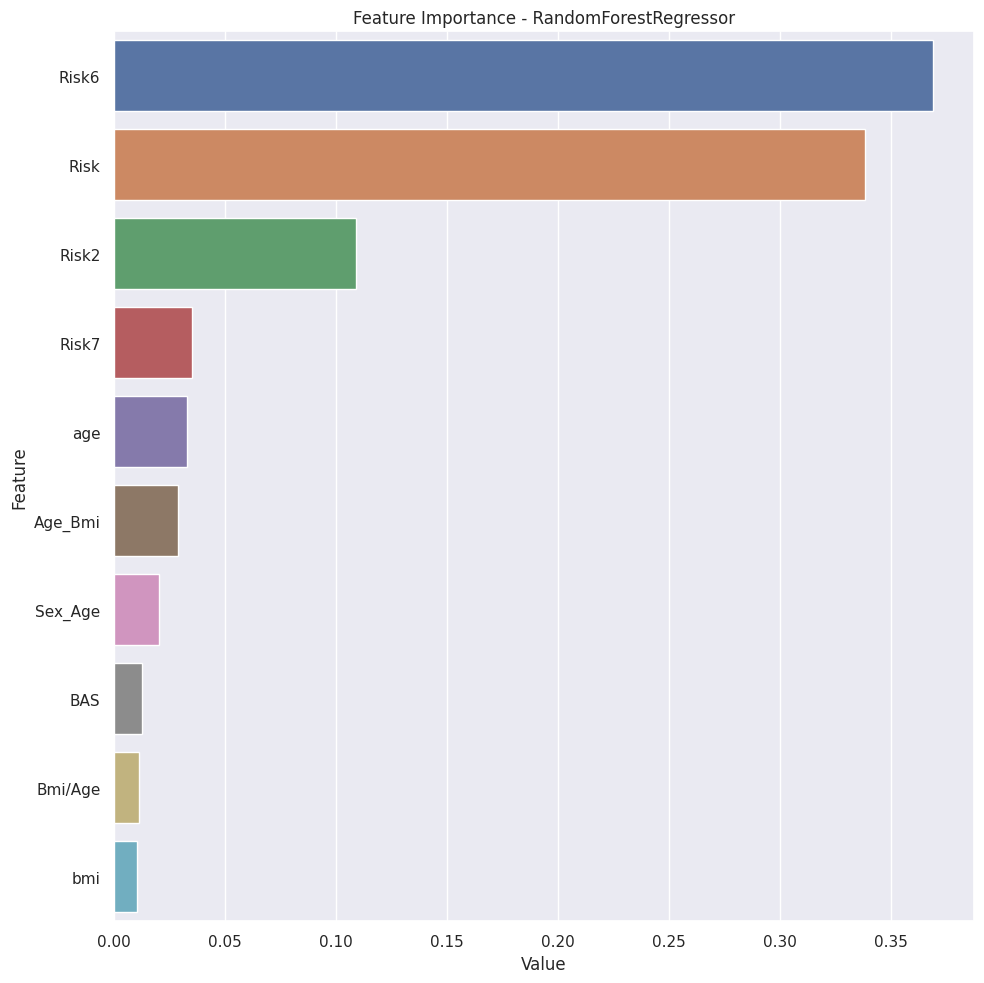

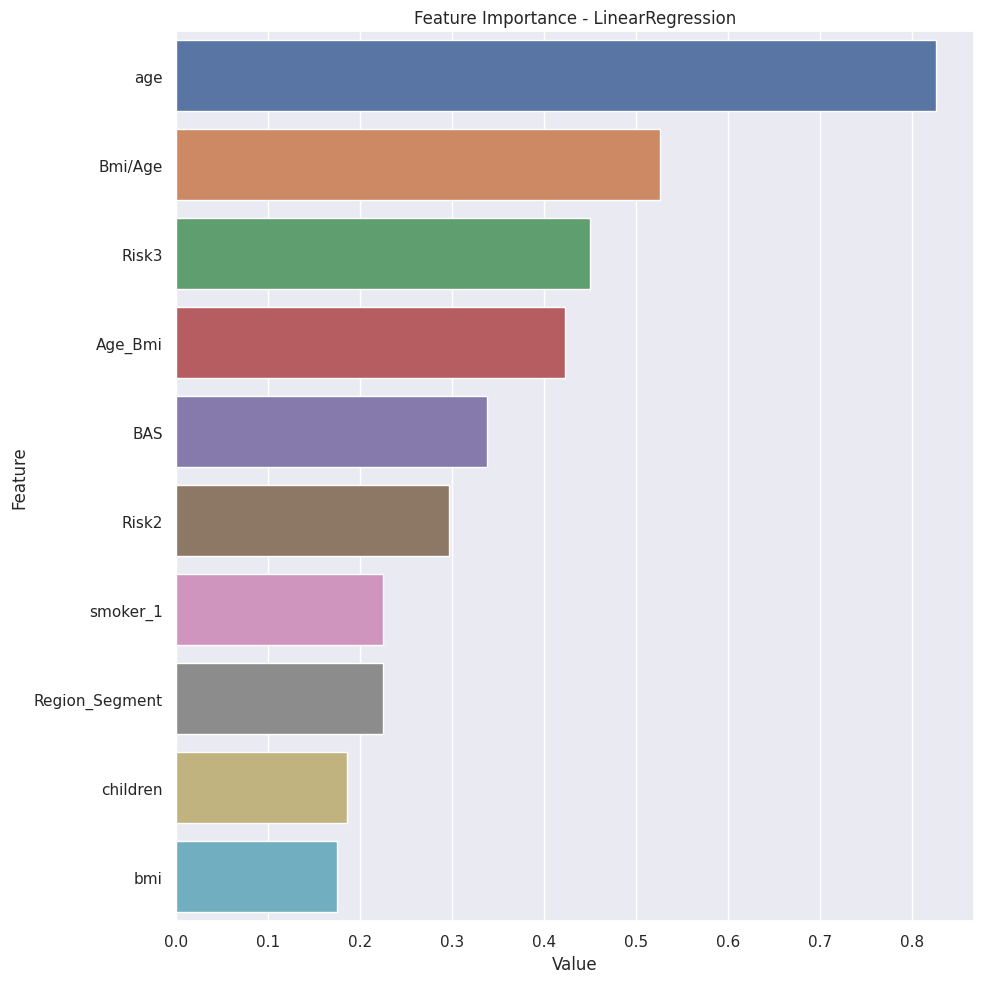

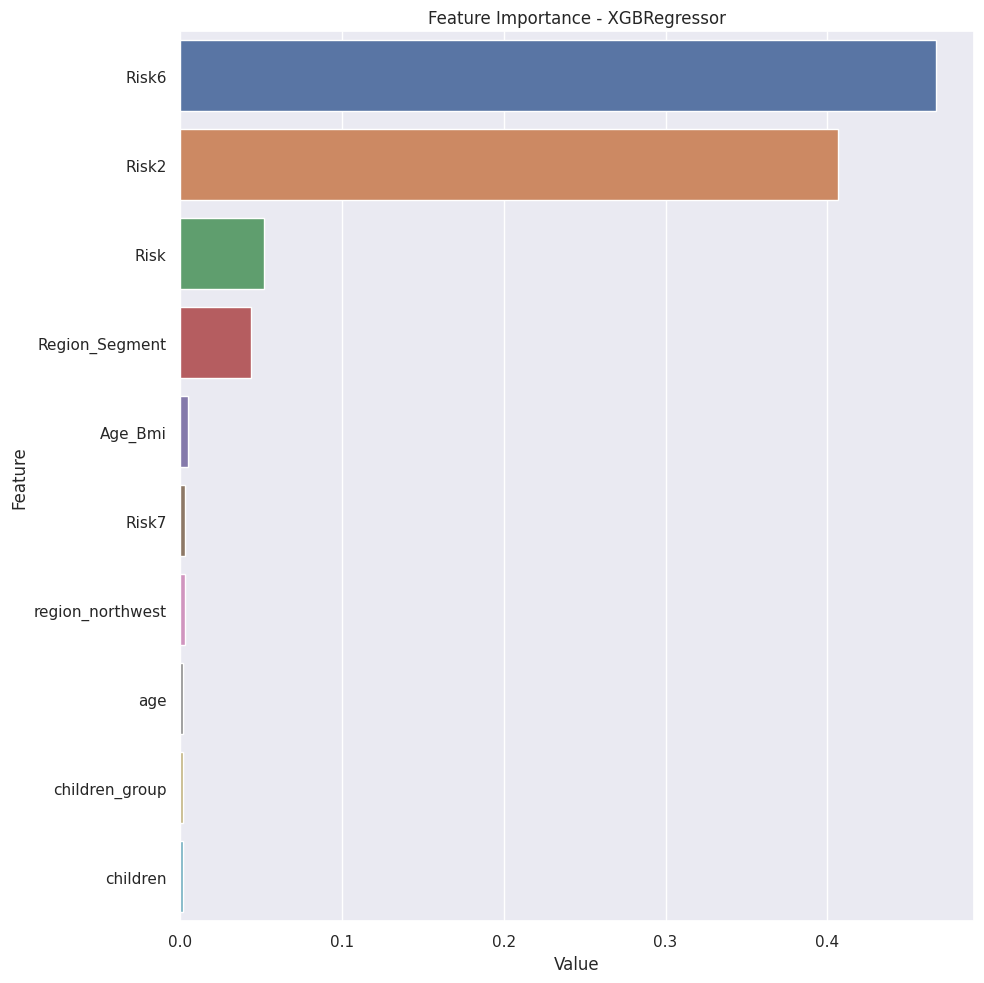

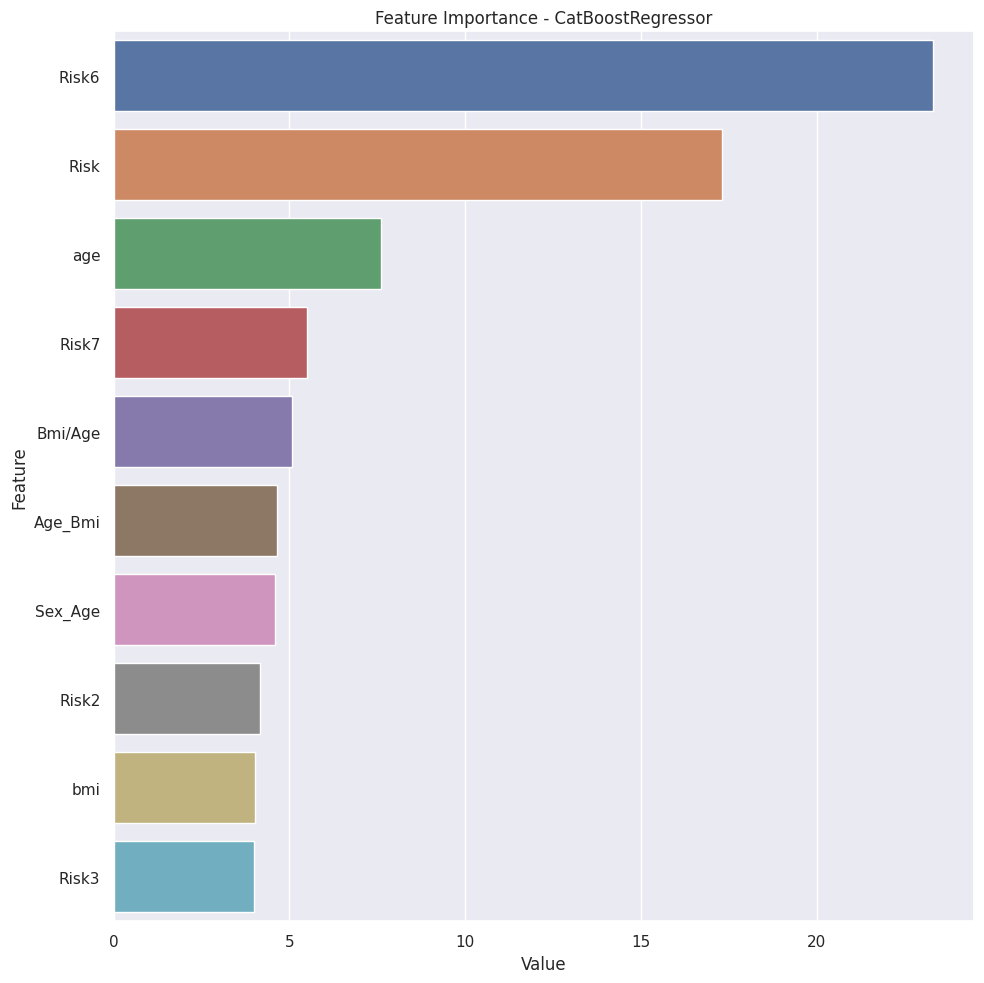

In [53]:
from sklearn.linear_model import LinearRegression  # LogisticRegression yerine
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

def plot_importance(model, features, num=None, save=False):
    # Plotlanacak özellik sayısını varsayılan olarak sütun sayısı olarak ayarla
    if num is None:
        num = len(features.columns)

    # Modelin feature importance özelliğini kontrol et
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        # LogisticRegression gibi modeller için
        importances = model.coef_[0] if model.coef_.ndim == 2 else model.coef_
        importances = np.abs(importances)
    else:
        print(f"{model.__class__.__name__} modelinde özellik önem değerleri bulunamadı.")
        return

    feature_imp = pd.DataFrame({'Value': importances, 'Feature': features.columns})

    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature",
                data=feature_imp.sort_values(by="Value", ascending=False).iloc[:num])
    plt.title(f'Feature Importance - {model.__class__.__name__}')
    plt.tight_layout()
    if save:
        plt.savefig(f'importances_{model.__class__.__name__}.png')
    plt.show()

# Örnek kullanım:
models = [
    RandomForestRegressor(),
    LinearRegression(),  # LogisticRegression yerine LinearRegression
    XGBRegressor(),
    CatBoostRegressor(verbose=False, random_state=12345)
]

# X ve y eğitim verisi (örnek)
# X = ...  # Özellikler
# y = ...  # Etiketler

for model in models:
    model.fit(X, y)
    plot_importance(model, X, num=10, save=False)  # num: Görselleştireceğiniz özellik sayısı


# 20. Final Model


✅ Final Model Performance (Random Forest)
RMSE: 0.3653
R² Score: 0.8783
MAE: 0.2106
MSE: 0.1334


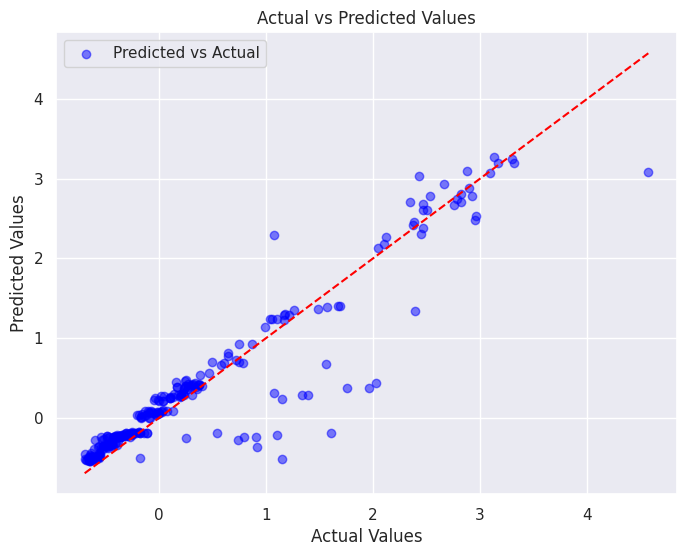

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# En iyi modeli belirleme
best_model_name = "RF"  # En iyi model Random Forest
best_params = optimized_df.loc[optimized_df['Model'] == best_model_name, 'Best Params'].values[0]

# Modeli oluştur ve en iyi parametreleri uygula
final_model = RandomForestRegressor(**best_params)
final_model.fit(X_train, y_train)

# Test seti üzerinde tahmin yap
y_pred = final_model.predict(X_test)

# Performans metriklerini hesapla
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Sonuçları yazdır
print("\n✅ Final Model Performance (Random Forest)")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")

# Gerçek ve tahmin edilen değerleri çizdirme
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.5, label="Predicted vs Actual")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()
